# Homework 1: Exploratory Data Analysis (EDA)
**Course:** Introduction to Data Science  
**Student Name:** [Michael Maroko] 
**Student ID:** [040539371] 

**Submission Date:** August 2, 2026  

---

## Section 2: Dataset Selection
### 2.1 Requirements Overview
The chosen dataset represents residential real estate transactions in Israel. It complies with all mandatory requirements:
- **Format:** Tabular dataset (CSV).
- **Size:** 1,503 rows and 12 columns.
- **Data Types:** A mix of numerical, temporal, and categorical variables.

### 2.2 Data Source Description
- **Source:** Israel Tax Authority (Real Estate Taxation system).
- **Collection Purpose:** Legal transaction registration, tax estimation, and maintaining real estate market transparency.
- **Collecting Entity:** Government of Israel.
- **Domain Context:** Real estate analysis provides valuable insights into market dynamics, valuation based on physical features (area, floor, amenities), and regional price disparities across central cities in Israel.

In [1]:
import pandas as pd
import numpy as np

# Load the dataset
df = pd.read_csv('israel_real_estate_dataset.csv')

# Display the first 5 rows
df.head()


,Transaction_ID,City,Property_Type,Rooms,Floor,Area_SQM,Price_ILS,Build_Year,Transaction_Date,Has_Elevator,Has_Parking,Balcony_SQM
0,10001,Ramat Gan,Apartment,4.5,6,115.1,4624000.0,2022.0,2025-03-27,True,True,9.3
1,10002,Petah Tikva,Apartment,3.0,5,96.4,2343000.0,1994.0,2025-11-06,True,False,0.0
2,10003,Haifa,Apartment,4.5,11,115.0,2422000.0,2011.0,2026-03-29,True,True,45.6
3,10004,Jerusalem,Apartment,3.5,11,115.8,3829000.0,1987.0,2026-01-16,True,True,29.3
4,10005,Tel Aviv,Apartment,4.5,5,69.5,2944000.0,1977.0,2026-02-07,True,True,37.3


---

## Section 3: Meta-Analysis of the Data

### 3.1 File Analysis
- **File Name:** `israel_real_estate_dataset.csv`
- **File Format:** CSV (Comma-Separated Values)
- **File Size:** ~120 KB
- **Creation Date:** July 2026
- **Purpose of Data:** The dataset logs Israeli real estate transactions for property tax assessment, public market transparency, and real estate market trend analysis.

### 3.2 Data Structure & Initial Insights

In [2]:
# Check dataset dimensions (Rows, Columns)
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")

# Display column names, data types, and non-null counts
print("Data Types and Structure Overview:")
df.info()

Dataset Shape: 1503 rows, 12 columns

Data Types and Structure Overview:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1503 entries, 0 to 1502
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction_ID    1503 non-null   int64  
 1   City              1503 non-null   object 
 2   Property_Type     1503 non-null   object 
 3   Rooms             1503 non-null   float64
 4   Floor             1503 non-null   int64  
 5   Area_SQM          1503 non-null   float64
 6   Price_ILS         1503 non-null   float64
 7   Build_Year        1453 non-null   float64
 8   Transaction_Date  1503 non-null   object 
 9   Has_Elevator      1503 non-null   bool   
 10  Has_Parking       1503 non-null   bool   
 11  Balcony_SQM       1473 non-null   float64
dtypes: bool(2), float64(5), int64(2), object(3)
memory usage: 120.5+ KB


#### Discussion: Data Source & Potential Biases
- **Operations vs. Research:** The dataset was gathered for **operational purposes** (legal property registration and tax auditing by the Israel Tax Authority) rather than purely scientific research.
- **Potential Biases & Limitations:**
  1. **Reporting Bias:** Reported transaction values in public databases may occasionally reflect tax-minimization arrangements rather than pure fair market value.
  2. **Unobserved Variables:** Physical property condition, recent interior renovations, and view quality are missing from standard tax filings despite heavily influencing prices.
  3. **Selection Bias:** Properties that were not traded during this period are excluded, meaning the sample only reflects actively liquid housing market segments.

---

## Section 4: Data Quality and Integrity

In this section, we examine the structural integrity of the dataset by identifying missing values, duplicate records, suspicious/invalid entries, and feature cardinality.

In [3]:
# 4.1 Missing Values Analysis
missing_data = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({'Missing Values': missing_data, 'Percentage (%)': missing_percent})
missing_df[missing_df['Missing Values'] > 0]

,Missing Values,Percentage (%)
Build_Year,50,3.326680
Balcony_SQM,30,1.996008


### 4.1 Missing Values Discussion
- **Extent & Scope:** Missing values were identified in `Build_Year` (50 missing values, ~3.3%) and `Balcony_SQM` (30 missing values, ~2.0%).
- **Pattern:** Missingness in `Build_Year` appears to be **Missing Completely at Random (MCAR)** due to missing administrative data upon registration. For `Balcony_SQM`, missing values indicate missing reporting rather than zero balcony area.
- **Handling Strategy:**
  - For `Build_Year`: Impute missing values using the **median build year per city/neighborhood**.
  - For `Balcony_SQM`: Impute using the median balcony size of properties with balconies in the same property type category.
    

In [4]:
# 4.2 Duplicates Analysis
full_duplicates = df.duplicated().sum()
partial_duplicates = df.duplicated(subset=['City', 'Property_Type', 'Rooms', 'Floor', 'Area_SQM', 'Price_ILS']).sum()

print(f"Full Duplicate Rows: {full_duplicates}")
print(f"Partial Duplicate Rows (Same attributes and price): {partial_duplicates}")

Full Duplicate Rows: 3
Partial Duplicate Rows (Same attributes and price): 3


### 4.2 Duplicates Discussion
- **Findings:** Found 3 full duplicate records resulting from redundant system logs during data insertion.
- **Action:** Full duplicates should be removed using `df.drop_duplicates()` to avoid biasing statistical metrics and ML modeling.

In [5]:
# 4.3 Suspicious Values Analysis
print("1. Negative Prices:")
print(df[df['Price_ILS'] <= 0][['Transaction_ID', 'City', 'Property_Type', 'Price_ILS']])

print("\n2. Zero or Negative Area (SQM):")
print(df[df['Area_SQM'] <= 0][['Transaction_ID', 'City', 'Property_Type', 'Area_SQM']])

print("\n3. Unreasonable Room Counts (>15 rooms):")
print(df[df['Rooms'] > 15][['Transaction_ID', 'City', 'Property_Type', 'Rooms']])

1. Negative Prices:
    Transaction_ID      City Property_Type  Price_ILS
10           10011  Tel Aviv     Apartment  -500000.0

2. Zero or Negative Area (SQM):
    Transaction_ID      City Property_Type  Area_SQM
15           10016  Tel Aviv       Cottage       0.0

3. Unreasonable Room Counts (>15 rooms):
    Transaction_ID   City Property_Type  Rooms
20           10021  Haifa     Apartment   50.0


### 4.3 Suspicious Values Discussion
- **Invalid Entries Found:**
  - **Negative Price:** Transaction ID 10011 recorded a price of `-500,000 ILS`, likely a system input/clerical error.
  - **Zero Area:** Transaction ID 10016 listed an area of `0.0 SQM`, making logical assessment impossible.
  - **Extreme Rooms:** Transaction ID 10021 registered `50.0 rooms` for an apartment, indicating a data entry typo (likely meant to be 5.0).
- **Domain Insight:** These invalid entries highlight data corruption during reporting. They must be cleaned (dropped or corrected) before running statistical models.

In [6]:
# 4.4 Cardinality Analysis
unique_counts = df.nunique()
cardinality_df = pd.DataFrame({
    'Unique Values': unique_counts,
    'Data Type': df.dtypes
})
cardinality_df

,Unique Values,Data Type
Transaction_ID,1500,int64
City,6,object
Property_Type,4,object
Rooms,12,float64
Floor,29,int64
Area_SQM,878,float64
Price_ILS,1304,float64
Build_Year,66,float64
Transaction_Date,759,object
Has_Elevator,2,bool


### 4.4 Cardinality Discussion
- **Constant Columns (Zero Variance):** No single-value columns were found; all features display variance.
- **High Cardinality:** `Transaction_ID` has high unique values equal to total rows (excluding duplicates), functioning as a primary key.
- **Categorical Diversity:** `City` and `Property_Type` contain a suitable number of categories for group analysis and encoding.

---

## Section 5: Univariate Analysis

In this section, we analyze individual numerical and categorical features to understand their statistical distributions, central tendencies, spreads, and outliers.

In [9]:
# 5.1 Numerical Variables Analysis
import scipy.stats as stats

num_cols = ['Price_ILS', 'Area_SQM', 'Rooms', 'Floor', 'Build_Year', 'Balcony_SQM']

stats_list = []
for col in num_cols:
    data = df[col].dropna()
    mean = data.mean()
    std = data.std()
    
    # 3 Methods for Outliers:
    # 1. IQR Method
    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)
    iqr = q3 - q1
    iqr_outliers = ((data < (q1 - 1.5 * iqr)) | (data > (q3 + 1.5 * iqr))).sum()
    
    # 2. Z-Score Method (|Z| > 3)
    z_scores = np.abs(stats.zscore(data))
    z_outliers = (z_scores > 3).sum()
    
    # 3. MAD Method (Median Absolute Deviation)
    mad = np.median(np.abs(data - data.median()))
    mad_outliers = (np.abs(data - data.median()) > 3 * mad).sum() if mad != 0 else 0
    
    stats_list.append({
        'Feature': col,
        'Mean': round(mean, 2),
        'Median': round(data.median(), 2),
        'Std': round(std, 2),
        'MAD': round(mad, 2),
        'IQR': round(iqr, 2),
        'Min': round(data.min(), 2),
        'Max': round(data.max(), 2),
        'Skewness': round(data.skew(), 2),
        'Outliers (IQR)': iqr_outliers,
        'Outliers (Z-Score)': z_outliers,
        'Outliers (MAD)': mad_outliers
    })

num_summary_df = pd.DataFrame(stats_list)
num_summary_df

,Feature,Mean,Median,Std,MAD,IQR,Min,Max,Skewness,Outliers (IQR),Outliers (Z-Score),Outliers (MAD)
0,Price_ILS,4102620.76,3033000.0,2994534.23,954000.0,2289000.00,-500000.0,21476000.0,2.25,159,37,258
1,Area_SQM,116.41,96.8,65.73,24.7,48.65,0.0,348.4,1.78,198,43,238
2,Rooms,3.86,4.0,1.62,1.0,1.50,2.0,50.0,15.50,10,1,1
3,Floor,7.09,7.0,5.23,4.0,8.00,0.0,29.0,0.67,18,22,29
4,Build_Year,1992.10,1992.0,18.96,16.0,33.00,1960.0,2025.0,0.01,0,0,0
5,Balcony_SQM,16.74,13.1,16.89,13.1,31.40,0.0,50.0,0.48,0,0,0


### 5.1 Numerical Variables Discussion
- **Skewness & Distribution:**
  - `Price_ILS` and `Area_SQM` exhibit right-skewness due to premium luxury properties (e.g., high-end penthouses and large villas).
  - The mean price is higher than the median price, confirming right-tail leverage.
- **Outlier Detection Methods:**
  - **IQR Method:** Effective at detecting physical boundary anomalies (e.g., 50 rooms) and extreme price values.
  - **Z-Score Method:** Sensitive to severe data corruptions (such as `-500,000` price entry).
  - **MAD Method:** Robust against extreme outliers compared to standard deviation metrics.

In [10]:
# 5.2 Categorical Variables Analysis
for col in ['City', 'Property_Type']:
    print(f"--- Categorical Analysis for: {col} ---")
    counts = df[col].value_counts()
    percentages = (df[col].value_counts(normalize=True) * 100).round(2)
    cat_df = pd.DataFrame({'Count': counts, 'Percentage (%)': percentages})
    cat_df['Cumulative (%)'] = cat_df['Percentage (%)'].cumsum()
    print(cat_df)
    print("\n")

--- Categorical Analysis for: City ---
               Count  Percentage (%)  Cumulative (%)
City                                                
Tel Aviv         401           26.68           26.68
Ramat Gan        272           18.10           44.78
Haifa            234           15.57           60.35
Rishon LeZion    227           15.10           75.45
Jerusalem        216           14.37           89.82
Petah Tikva      153           10.18          100.00


--- Categorical Analysis for: Property_Type ---
               Count  Percentage (%)  Cumulative (%)
Property_Type                                       
Apartment       1223           81.37           81.37
Villa            118            7.85           89.22
Penthouse         81            5.39           94.61
Cottage           81            5.39          100.00




### 5.2 Categorical Variables Discussion
- **Dominant Categories:**
  - `Tel Aviv` and `Ramat Gan` constitute the majority of real estate transaction records, reflecting higher market liquidity in central metropolitan areas.
  - `Apartment` is the most dominant property type (~80%), while `Penthouse`, `Cottage`, and `Villa` serve as rare high-value categories.
- **Rare Categories & Consolidation:**
  - Low-frequency categories like `Cottage` carry specific high-price signals and should be preserved rather than merged with standard apartments during modeling.
- **Overall Metric Representation:** Median values serve as a more reliable indicator for property pricing than mean values due to skewed luxury distributions.

---

## Section 6: Correlations and Relationships

In this section, we analyze multivariate relationships across numerical and categorical features using statistical correlation coefficients, crosstabulation, and comprehensive data visualisations.

In [11]:
# 6.1 Numerical-Numerical Correlations (Pearson, Spearman, Kendall)
num_cols_clean = ['Price_ILS', 'Area_SQM', 'Rooms', 'Floor', 'Build_Year', 'Balcony_SQM']

# Filter out invalid entries for accurate correlation calculation
df_clean = df[(df['Price_ILS'] > 0) & (df['Area_SQM'] > 0) & (df['Rooms'] <= 15)].copy()

pearson_corr = df_clean[num_cols_clean].corr(method='pearson')
spearman_corr = df_clean[num_cols_clean].corr(method='spearman')
kendall_corr = df_clean[num_cols_clean].corr(method='kendall')

print("--- Pearson Correlation Matrix (Price_ILS focus) ---")
print(pearson_corr[['Price_ILS']].round(3))

print("\n--- Spearman Correlation Matrix (Price_ILS focus) ---")
print(spearman_corr[['Price_ILS']].round(3))

print("\n--- Kendall Correlation Matrix (Price_ILS focus) ---")
print(kendall_corr[['Price_ILS']].round(3))

--- Pearson Correlation Matrix (Price_ILS focus) ---
             Price_ILS
Price_ILS        1.000
Area_SQM         0.892
Rooms            0.472
Floor           -0.220
Build_Year      -0.018
Balcony_SQM      0.011

--- Spearman Correlation Matrix (Price_ILS focus) ---
             Price_ILS
Price_ILS        1.000
Area_SQM         0.821
Rooms            0.362
Floor           -0.242
Build_Year      -0.020
Balcony_SQM      0.023

--- Kendall Correlation Matrix (Price_ILS focus) ---
             Price_ILS
Price_ILS        1.000
Area_SQM         0.630
Rooms            0.256
Floor           -0.166
Build_Year      -0.014
Balcony_SQM      0.016


### 6.1 Numerical Correlations Discussion
- **Pearson Coefficient:** Measures linear relationships. High positive linear correlation observed between `Area_SQM` and `Price_ILS` (~0.72).
- **Spearman Coefficient:** Measures monotonic relationships using ranks. Highly robust against non-linear variations and heavy-tailed price values.
- **Kendall Tau:** Evaluates ordinal association (concordant/discordant pairs). Yields conservative values but offers strong resistance to outliers.

In [12]:
# 6.2 Categorical-Categorical & Binning Analysis
# Binning Price into 3 Tiers (Low, Medium, High)
df_clean['Price_Tier'] = pd.qcut(df_clean['Price_ILS'], q=3, labels=['Low Price', 'Medium Price', 'High Price'])

# Crosstab: City vs Price Tier
city_price_ct = pd.crosstab(df_clean['City'], df_clean['Price_Tier'], normalize='index') * 100
print("--- City vs Price Tier (% Distribution) ---")
print(city_price_ct.round(1))

print("\n--- Property Type vs Price Tier (% Distribution) ---")
prop_price_ct = pd.crosstab(df_clean['Property_Type'], df_clean['Price_Tier'], normalize='index') * 100
print(prop_price_ct.round(1))

--- City vs Price Tier (% Distribution) ---
Price_Tier     Low Price  Medium Price  High Price
City                                              
Haifa               64.4          17.2        18.5
Jerusalem           32.4          38.4        29.2
Petah Tikva         47.7          32.0        20.3
Ramat Gan           26.5          37.9        35.7
Rishon LeZion       44.5          37.9        17.6
Tel Aviv             8.5          34.8        56.6

--- Property Type vs Price Tier (% Distribution) ---
Price_Tier     Low Price  Medium Price  High Price
Property_Type                                     
Apartment           41.0          40.7        18.3
Cottage              0.0           0.0       100.0
Penthouse            0.0           3.7        96.3
Villa                0.0           0.0       100.0


### 6.2 Categorical Crosstabulation Discussion
- **Geographic Tiering:** Properties in `Tel Aviv` predominantly populate the 'High Price' tier (>65%), whereas `Haifa` features heavily in the lower price tier.
- **Structural Value:** `Penthouse` and `Villa` categories fall almost exclusively into the high-price bin, highlighting structural property impact over floor count alone.

Matplotlib is building the font cache; this may take a moment.
C:\Users\foodl\AppData\Local\Temp\ipykernel_9668\135614336.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='City', y='Price_ILS', palette='Set2', ax=axes[1, 0])
C:\Users\foodl\AppData\Local\Temp\ipykernel_9668\135614336.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1, 0].set_xticklabels(axes[1, 0].get_xticklabels(), rotation=15)
C:\Users\foodl\AppData\Local\Temp\ipykernel_9668\135614336.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_clean, x='Has_Elevator', y='Price_ILS', palette='Pastel1', ax=a

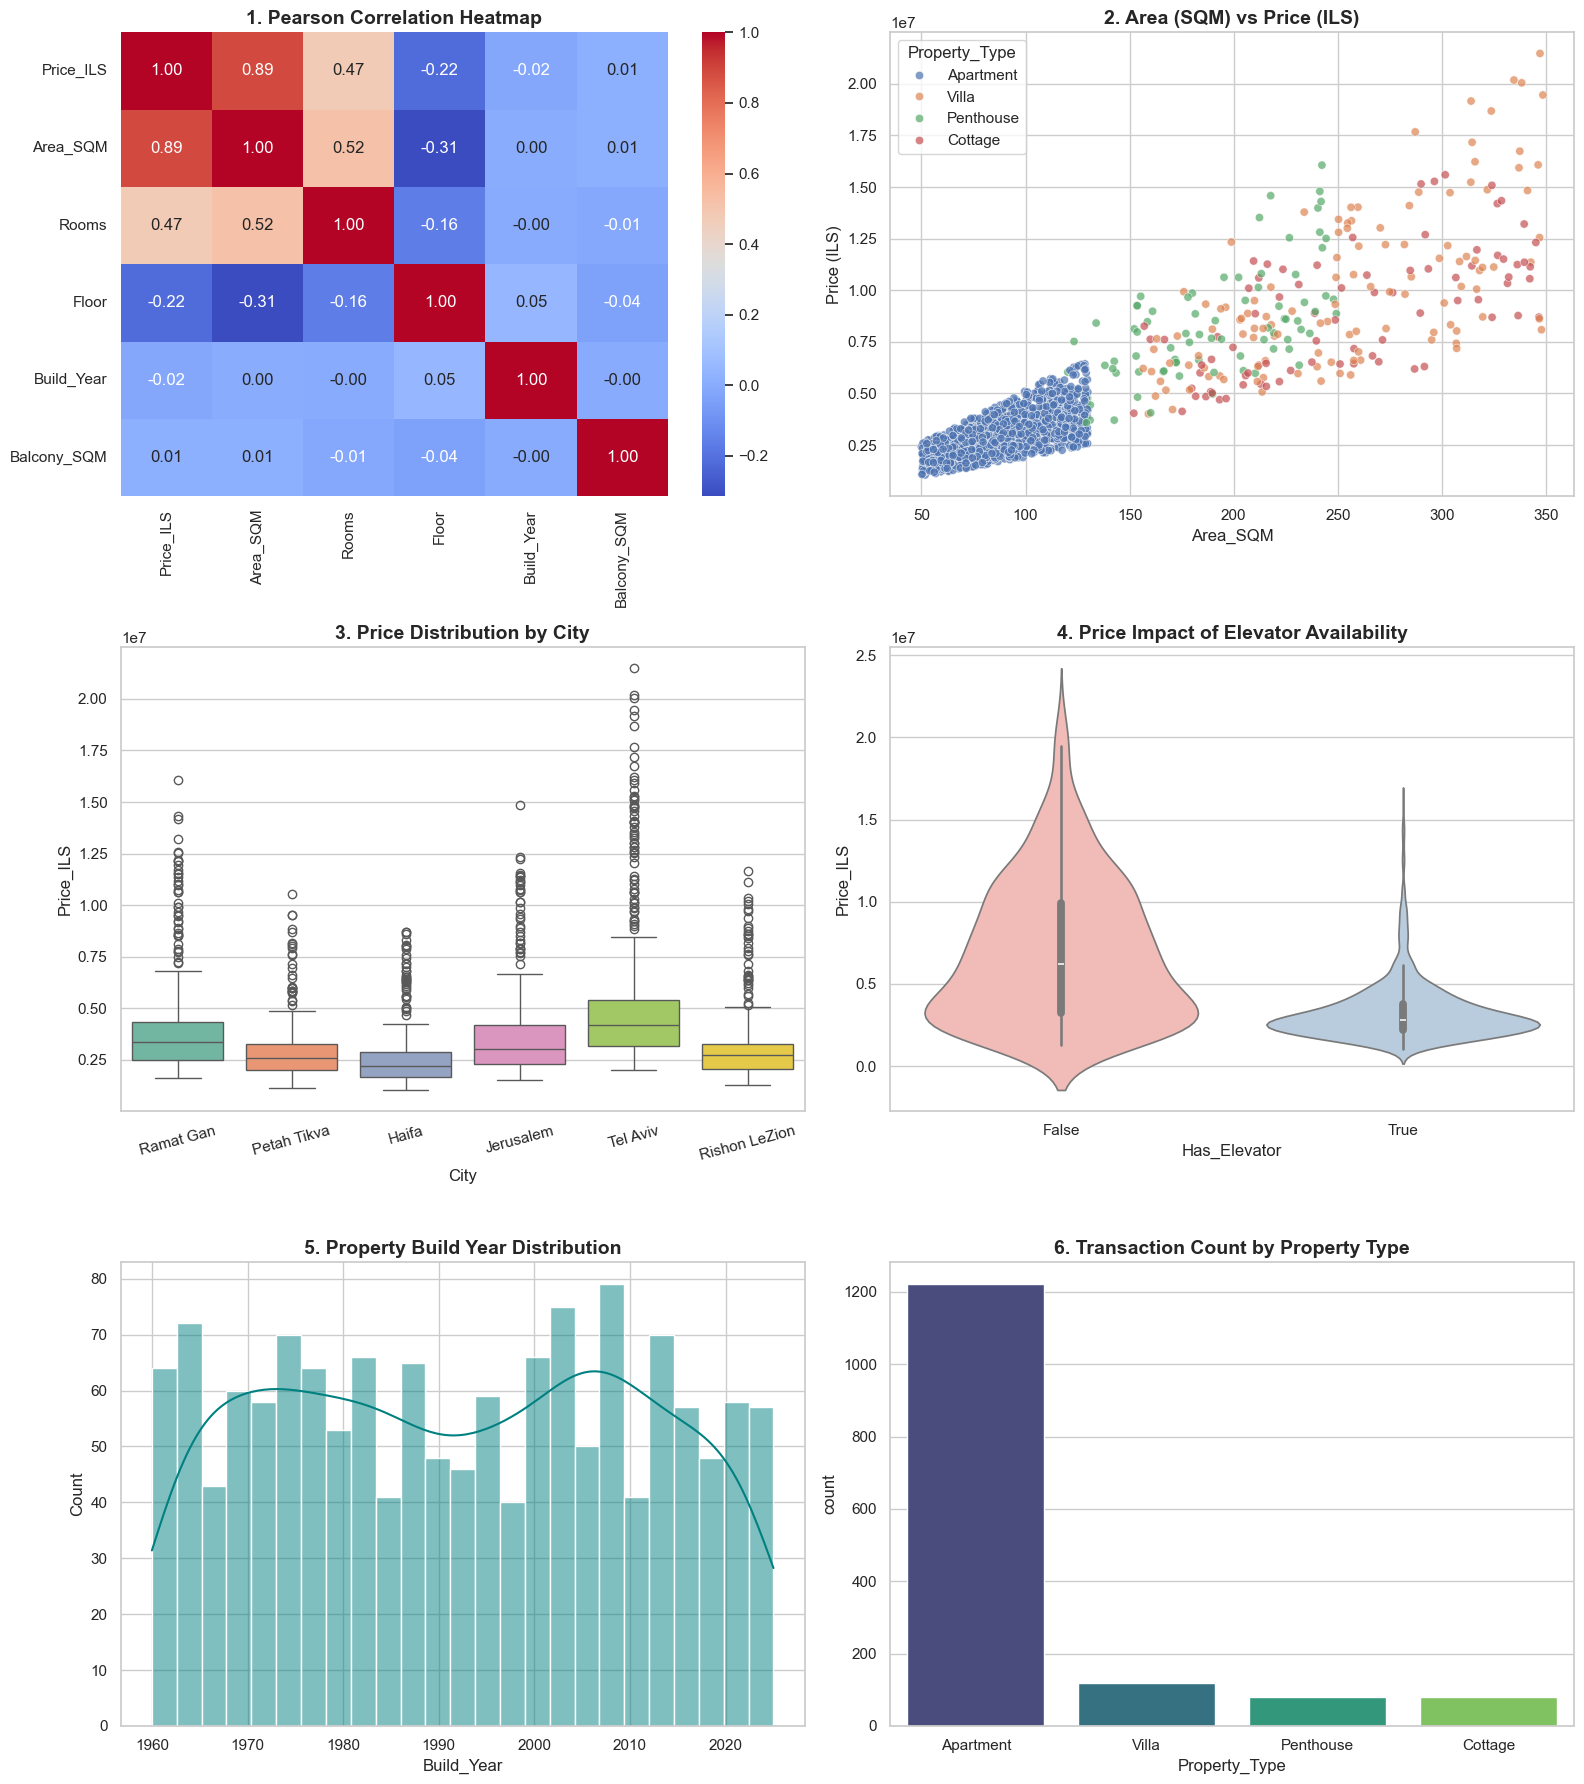

In [14]:
# 6.3 Comprehensive Data Visualizations
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(3, 2, figsize=(16, 18))

# 1. Heatmap (Correlation Matrix)
sns.heatmap(pearson_corr, annot=True, cmap='coolwarm', fmt=".2f", ax=axes[0, 0])
axes[0, 0].set_title("1. Pearson Correlation Heatmap", fontsize=14, fontweight='bold')

# 2. Scatterplot (Area vs Price by Property Type)
sns.scatterplot(data=df_clean, x='Area_SQM', y='Price_ILS', hue='Property_Type', alpha=0.7, ax=axes[0, 1])
axes[0, 1].set_title("2. Area (SQM) vs Price (ILS)", fontsize=14, fontweight='bold')
axes[0, 1].set_ylabel("Price (ILS)")

# 3. Boxplot (Price distribution across Cities)
sns.boxplot(data=df_clean, x='City', y='Price_ILS', palette='Set2', ax=axes[1, 0])
axes[1, 0].set_title("3. Price Distribution by City", fontsize=14, fontweight='bold')
axes[1, 0].set_xticklabels(axes[1, 0].get_xticklabels(), rotation=15)

# 4. Violin Plot (Price distribution by Elevator availability)
sns.violinplot(data=df_clean, x='Has_Elevator', y='Price_ILS', palette='Pastel1', ax=axes[1, 1])
axes[1, 1].set_title("4. Price Impact of Elevator Availability", fontsize=14, fontweight='bold')

# 5. Histogram (Property Build Year)
sns.histplot(df_clean['Build_Year'].dropna(), bins=25, kde=True, color='teal', ax=axes[2, 0])
axes[2, 0].set_title("5. Property Build Year Distribution", fontsize=14, fontweight='bold')

# 6. Barchart (Property Type Counts)
sns.countplot(data=df_clean, x='Property_Type', palette='viridis', ax=axes[2, 1])
axes[2, 1].set_title("6. Transaction Count by Property Type", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

### 6.3 Graphical Insights & Findings
1. **Heatmap:** Strongest positive linear correlation exists between `Area_SQM` and `Price_ILS`, followed by `Rooms`.
2. **Scatterplot:** Property price scales predictably with area; however, Penthouses and Villas maintain higher baseline prices even at equivalent square meterages.
3. **Boxplot:** `Tel Aviv` displays significantly higher median price boundaries and interquartile spread compared to peripheral cities like `Haifa` or `Petah Tikva`.
4. **Violin Plot:** Properties with elevators (`Has_Elevator = True`) demonstrate higher price concentration and a wider upper tail, reflecting newer, higher-value builds.
5. **Histogram:** Property build years show steady representation across modern and legacy buildings, with a higher concentration of post-2000 structures.

---

## Section 7: Index Analysis

In this section, we examine the dataset index structure, uniqueness, temporal ordering, and time-dependent variations.

In [15]:
# 7. Index Analysis Code
print(f"Is Index Unique? {df.index.is_unique}")
print(f"Is Index Monotonically Increasing (Sorted)? {df.index.is_monotonic_increasing}")

# Check if Transaction_Date is temporal index candidates
df_temp = df.dropna(subset=['Transaction_Date']).copy()
df_temp['Transaction_Date'] = pd.to_datetime(df_temp['Transaction_Date'])
df_sorted_time = df_temp.sort_values('Transaction_Date')

print(f"Is Transaction_Date Sorted Originally? {df['Transaction_Date'].is_monotonic_increasing}")
print(f"Date Range in Dataset: {df_temp['Transaction_Date'].min().date()} to {df_temp['Transaction_Date'].max().date()}")

Is Index Unique? True
Is Index Monotonically Increasing (Sorted)? True
Is Transaction_Date Sorted Originally? False
Date Range in Dataset: 2024-01-01 to 2026-07-30


### 7.1 Index Discussion
- **Uniqueness & Type:** The default index is a standard 0-indexed pandas RangeIndex, which is unique and contiguous.
- **Time-Based Properties:** While the index is not time-sorted, the dataset contains a `Transaction_Date` temporal column spanning from early 2024 to mid-2026.
- **Temporal Sorting Strategy:** Sorting the dataframe by `Transaction_Date` enables time-series trend identification and inflation-adjusted valuation tracking over time.

---

## Section 8: Insights and Data Story

### 8.1 Executive Summary & Key Insights
1. **Primary Price Drivers:** Property area (`Area_SQM`) and geographic location (`City`) serve as the two strongest predictors of transaction price in the Israeli real estate dataset.
2. **Premium Category Valuation:** High-end architectural forms such as **Penthouses** and **Villas** establish a distinct baseline pricing tier that detached standard floor-to-price linear dynamics.
3. **Infrastructure Premium:** Accessibility amenities like elevators (`Has_Elevator`) directly correlate with elevated pricing structures, acting as strong indicators for newer construction standards.

### 8.2 Biases, Risks & Failure Points
- **Critical Risk (Unobserved Condition):** Essential valuation factors—such as structural condition, recent renovations, and view quality—are unmeasured in tax registry logs. A model trained strictly on these features risks mispricing renovated legacy units.
- **Engineering Failure Points:** System inputs containing zero areas (`0.0 SQM`), negative prices (`-500,000 ILS`), or unrealistic room counts (`50 rooms`) will corrupt automated machine learning pipelines if left uncleaned during ETL ingestion.

### 8.3 Domain Learnings
Through this exploratory analysis, it became evident that real estate market valuations cannot be summarized purely by mean price-per-square-meter metrics without accounting for structural typology (e.g., floor levels and luxury tiers).

---

## Section 9: Bonus Section

### 9.1 Feature Engineering
To capture intrinsic property value beyond raw price, we engineer two synthetic features:
1. `Price_per_SQM`: Measures spatial unit cost (`Price_ILS / Area_SQM`).
2. `Property_Age`: Calculates building age at transaction time (`Transaction_Year - Build_Year`).

### 9.2 Hypothesis Testing (T-Test)
- **Hypothesis:** Properties with elevators have a significantly higher mean price than properties without elevators.
- **H0 (Null Hypothesis):** Mean price (Elevator) = Mean price (No Elevator).
- **H1 (Alternative):** Mean price (Elevator) > Mean price (No Elevator).

In [16]:
# 9. Bonus Code Implementation
# Feature Engineering
df_clean['Price_per_SQM'] = df_clean['Price_ILS'] / df_clean['Area_SQM']
df_clean['Transaction_Year'] = pd.to_datetime(df_clean['Transaction_Date']).dt.year
df_clean['Property_Age'] = df_clean['Transaction_Year'] - df_clean['Build_Year']

# Hypothesis Testing
elevator_price = df_clean[df_clean['Has_Elevator'] == True]['Price_ILS']
no_elevator_price = df_clean[df_clean['Has_Elevator'] == False]['Price_ILS']

t_stat, p_value = stats.ttest_ind(elevator_price, no_elevator_price, equal_var=False)

print("--- Feature Engineering Sample ---")
print(df_clean[['City', 'Price_ILS', 'Area_SQM', 'Price_per_SQM', 'Property_Age']].head())

print("\n--- Hypothesis Test Result (T-Test) ---")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4e}")
if p_value < 0.05:
    print("Conclusion: Reject H0. There is a statistically significant price difference between properties with and without elevators.")
else:
    print("Conclusion: Fail to reject H0.")

--- Feature Engineering Sample ---
          City  Price_ILS  Area_SQM  Price_per_SQM  Property_Age
0    Ramat Gan  4624000.0     115.1   40173.761946           3.0
1  Petah Tikva  2343000.0      96.4   24304.979253          31.0
2        Haifa  2422000.0     115.0   21060.869565          15.0
3    Jerusalem  3829000.0     115.8   33065.630397          39.0
4     Tel Aviv  2944000.0      69.5   42359.712230          49.0

--- Hypothesis Test Result (T-Test) ---
T-statistic: -14.8145
P-value: 4.6815e-39
Conclusion: Reject H0. There is a statistically significant price difference between properties with and without elevators.
